# Setup using Python and R in same file

Run this for R to work using %%R as the first line in a Python cell

In [4]:
# should run every time you open the notebook (connect to the kernel)
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


First import the relevant packages

In [5]:
# import
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf

Now import relevant timeseries, plot it, and download as .csv

In [30]:
# Download the S&P 500 data
sp500 = yf.download("^GSPC", start="1990-01-01", end="2025-12-31", interval="1mo")
sp500 = sp500.rename(columns={"^GSPC": "SP500"})

[*********************100%***********************]  1 of 1 completed


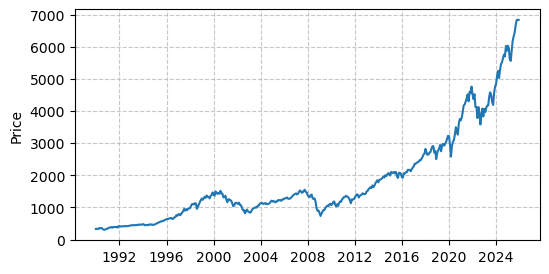

In [31]:
# save as .csv with column name as sp500
sp500['Close'].to_csv("sp500.csv")

# plot
plt.figure(figsize=(6, 3))
plt.plot(sp500['Close'])
plt.grid(True, alpha = 0.7, linestyle = '--')
plt.ylabel('Price')
plt.show()

Test with exuber in R

In [33]:
%%R
library(exuber)

dat <- read.csv('sp500.csv')
y   <- ts(dat$SP500)
T   <- length(y)
res  <- radf(y, lag = 0)
cv   <- radf_mc_cv(n = T, nrep = 1999, seed = 123)

options(digits = 10)

print(res)
print(cv)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  3.343935  3.598056  3.881435

  gsadf_panel
     3.881435


── Monte Carlo (minw = 41, nrep = 1999) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.3961043  1.152213  1.940305
   95  -0.0372898  1.450987  2.165981
   99   0.6329135  2.039816  2.622735



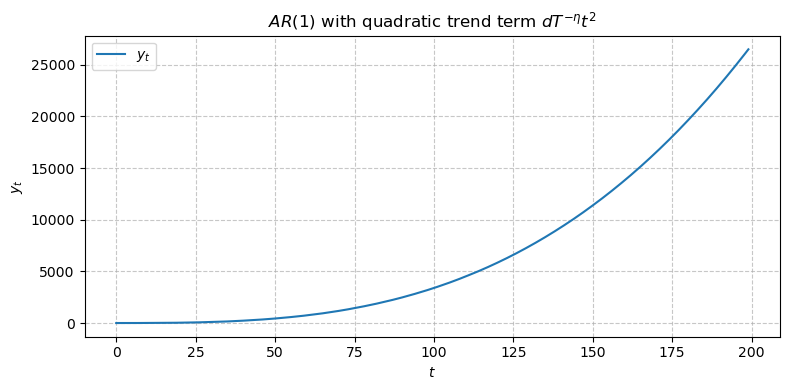

In [ ]:
# new simple simulation of AR(1) with the trend dT^{-eta}

# --- parameters ---
T = 200          # sample size
eta = 0.5
d = 1.0
theta = 1
sigma = 1.0
seed = 123

rng = np.random.default_rng(seed)

# --- simulate AR(1) with constant trend term d*T^{-eta} ---
y = np.zeros(T)
y[0] = 10

# quadratic deterministic drift: d*T^{-eta} * t^2
t_grid = np.arange(T)
trend_t = d * (T ** (-eta)) * (t_grid ** 2)

for t in range(1, T):
    eps_t = rng.normal(0.0, sigma)
    y[t] = trend_t[t] + theta * y[t - 1] + eps_t

# --- plot ---
plt.figure(figsize=(8, 4))
plt.plot(y, label="$y_t$")
plt.title(r"$AR(1)$ with quadratic trend term $d T^{-\eta} t^2$")
plt.xlabel("$t$")
plt.ylabel("$y_t$")
plt.legend()
plt.grid(True, alpha=0.7, linestyle="--")
plt.tight_layout()
plt.show()